In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np

from scipy.optimize import curve_fit

import h5py
from datetime import datetime
import sys
import os
import shutil
import importlib

sys.path.append(r"C:\Users\mattm\OneDrive\Desktop\Research\Projects\Triangle Lattice\Jupyter Notebooks\8Q_Triangle_Lattice_v1")


import current_measurements.src.src_current_measurement
importlib.reload(current_measurements.src.src_current_measurement)
from current_measurements.src.src_current_measurement import CurrentMeasurementCalibration, generate_ramp_beamsplitter_correlations_filename



import correlation_measurements.src_correlation_measurement
importlib.reload(correlation_measurements.src_correlation_measurement)
from correlation_measurements.src_correlation_measurement import RampOscillationShotsMeasurement, generate_ramp_double_jump_correlations_filename


In [4]:
config_filename = 'bond_order_config.json'

with open(config_filename, 'r') as f:
    config = json.load(f)

coupling_point = 'coupling_point_3'
eigenstate = 'highest'


coupling_point_config = config[coupling_point]


In [5]:
configuration_to_measurement = {}


In [6]:

# ### single correlation point

# correlation_pair = ((4,5),(7,8))
# correlation_pair_config = coupling_point_config['data_config'][str(correlation_pair)]
# configuration = correlation_pair_config['configuration']
    
   
# date_code_dict = correlation_pair_config[eigenstate]

# year = date_code_dict['year']
# month = date_code_dict['month']
# day = str(date_code_dict['day'])
# hour = date_code_dict['hour']
# minute = date_code_dict['minute']
# second = date_code_dict['second']

# filename = generate_ramp_beamsplitter_correlations_filename(year, month, day, hour, minute, second)

# configuration_to_measurement[configuration] = RampOscillationShotsMeasurement(filename)

In [7]:
def generate_filemame(filename_base, year, month, day, hour, minute, second):
    date_code = f'{year}_{month}_{day}'
    time_code = f'{hour}_{minute}_{second}'
    return r'V:\QSimMeasurements\Measurements\8QV1_Triangle_Lattice\{}\{}_{}\{}_{}_{}_data.h5'.format(filename_base, filename_base, date_code, filename_base, date_code, time_code)

In [8]:
path_base = r'V:\QSimMeasurements\Measurements\8QV1_Triangle_Lattice'

configurations = ['12-34-56-78', '1-23-45-67-8']
for configuration in configurations:

    if not str(configuration) in coupling_point_config['data_config']:
        print(f'skipping {configuration}')
        continue
    correlation_pair_config = coupling_point_config['data_config'][str(configuration)]

   
    if not eigenstate in correlation_pair_config:
        print(f'skipping {configuration}, {eigenstate} eigenstate')
        continue
   
    date_code_dict = correlation_pair_config[eigenstate]

    year = date_code_dict['year']
    month = date_code_dict['month']
    day = str(date_code_dict['day'])
    hour = date_code_dict['hour']
    minute = date_code_dict['minute']
    second = date_code_dict['second']


    filename_base = date_code_dict['filename_base']

    filename = generate_filemame(filename_base, year, month, day, hour, minute, second)

    if not configuration in configuration_to_measurement:
        configuration_to_measurement[configuration] = RampOscillationShotsMeasurement(filename)

In [9]:

configuration_to_times = {}
configuration_to_population_difference = {}
configuration_to_populations = {}

In [10]:

for configuration in configurations:
    measurement = configuration_to_measurement[configuration]

    print(configuration)
    print()



    times = measurement.get_times()
    populations = measurement.get_population_corrected_post_selected()

    if configuration == '12-34-56-78':
        population_differences = np.array([populations[i] - populations[i+1] for i in [0, 2, 4, 6]])
    elif configuration == '1-23-45-67-8':
        population_differences = np.array([populations[i] - populations[i+1] for i in [1, 3, 5]])
    else:
        population_differences = None

    parity = coupling_point_config['data_config'][str(configuration)]['parity']

    for i in range(population_differences.shape[0]):
        population_differences[i,:] *= parity[i]

    configuration_to_times[configuration] = times
    configuration_to_populations[configuration] = populations
    configuration_to_population_difference[configuration] = population_differences
    

12-34-56-78



FileNotFoundError: [Errno 2] Unable to open file (unable to open file: name = 'V:\QSimMeasurements\Measurements\8QV1_Triangle_Lattice\BSClean_Correlations\BSClean_Correlations_2026_01_11\BSClean_Correlations_2026_01_11_12_48_53_data.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
### organize data by qubit pair
pair_to_times = {}
pair_to_population_difference = {}
pair_to_populations = {}

for configuration in configurations:
    times = configuration_to_times[configuration]

    populations = configuration_to_populations[configuration]
    population_difference = configuration_to_population_difference[configuration]


    for i in range(population_difference.shape[0]):

        if configuration == '12-34-56-78':
            pair = (2*i+1, 2*i+2)
            label = f'Q{2*i+1}-Q{2*i+2}'
        elif configuration == '1-23-45-67-8':
            pair = (2*i+2, 2*i+3)
            label = f'Q{2*i+2}-Q{2*i+3}'

        pair_to_times[pair] = times
        pair_to_populations[pair] = np.array([populations[pair[0]-1,:], populations[pair[1]-1,:]])
        pair_to_population_difference[pair] = population_difference[i,:]

    

(1, 2)


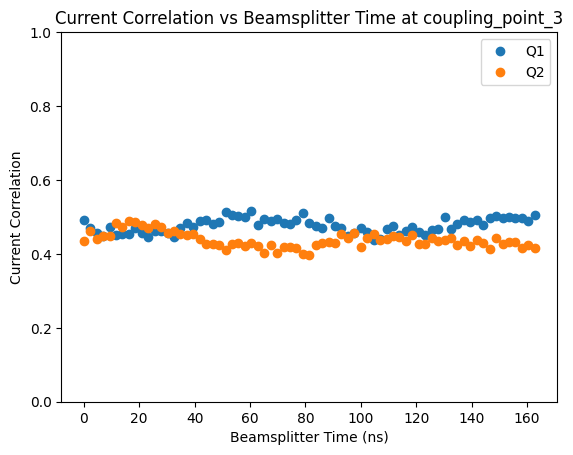

(3, 4)


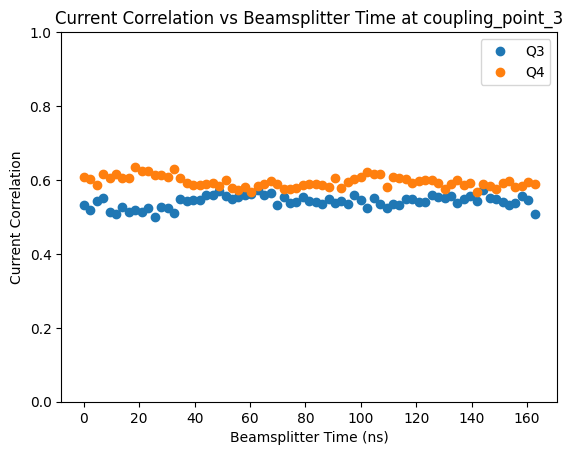

(5, 6)


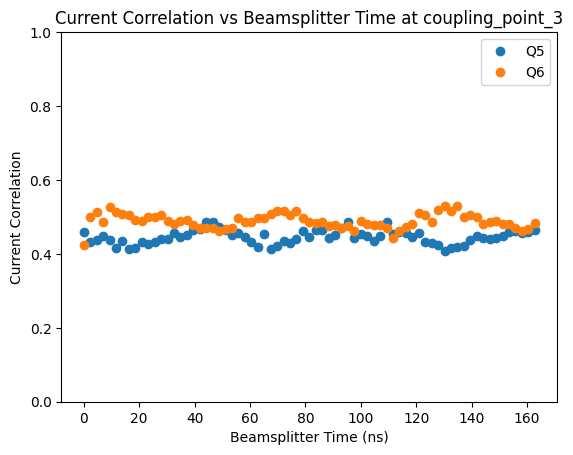

(7, 8)


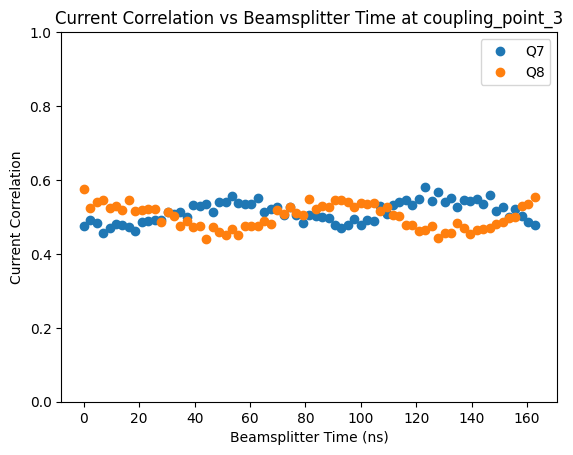

(2, 3)


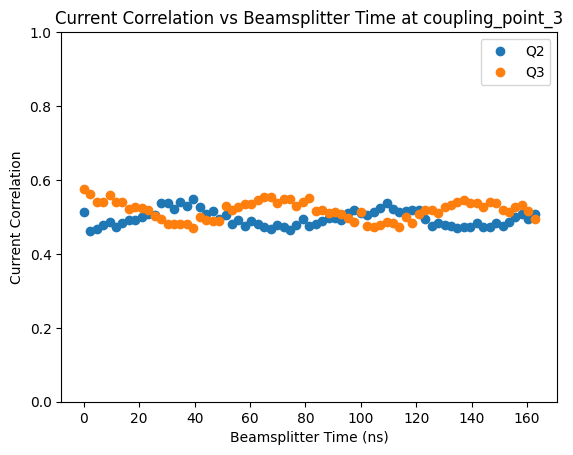

(4, 5)


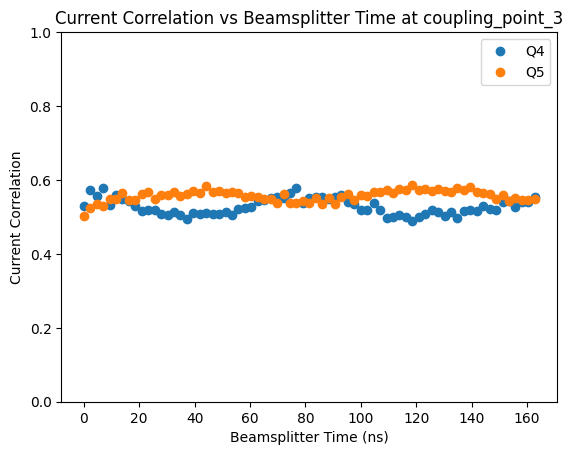

(6, 7)


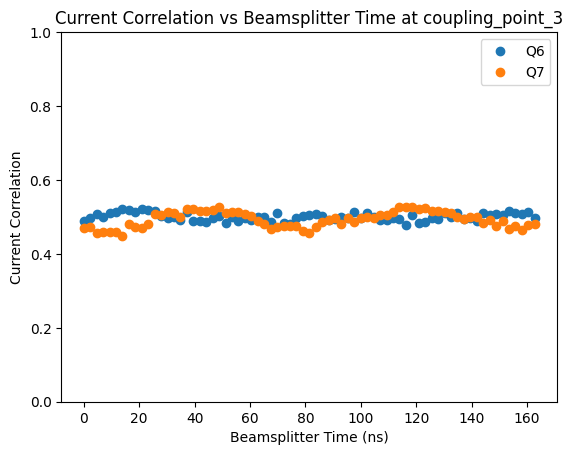

In [ ]:
for pair in pair_to_populations:
    print(pair)
    plt.plot(pair_to_times[pair], pair_to_populations[pair][0,:], linestyle='', marker='o', label=f'Q{pair[0]}')
    plt.plot(pair_to_times[pair], pair_to_populations[pair][1,:], linestyle='', marker='o', label=f'Q{pair[1]}')
    plt.xlabel('Beamsplitter Time (ns)')
    plt.ylabel('Current Correlation')
    plt.title(f'Current Correlation vs Beamsplitter Time at {coupling_point}')

    plt.ylim(0, 1)

    plt.legend()
    plt.show()

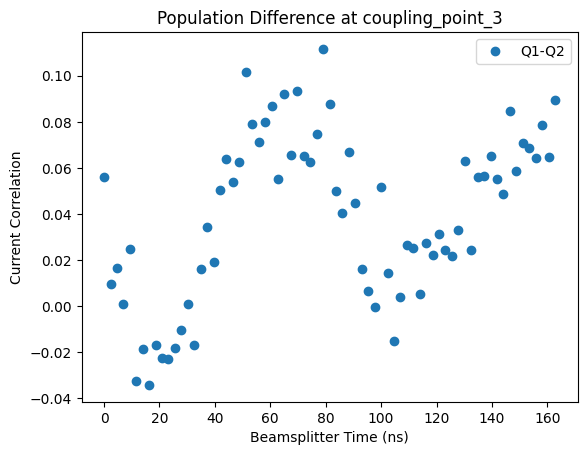

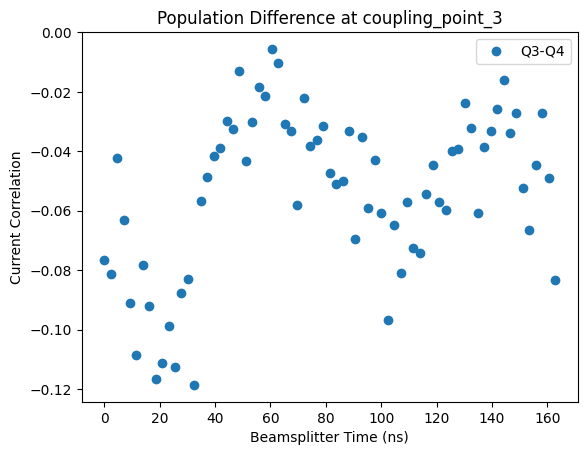

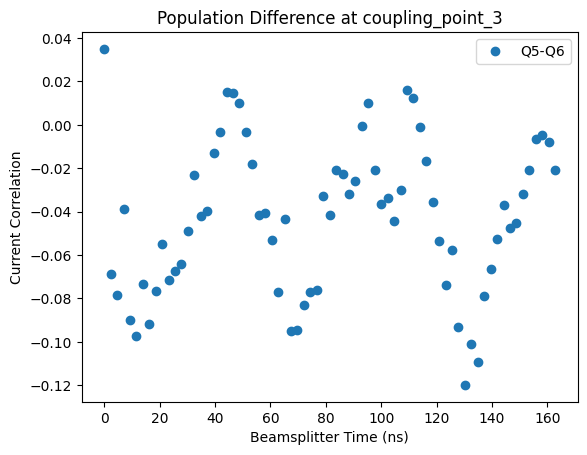

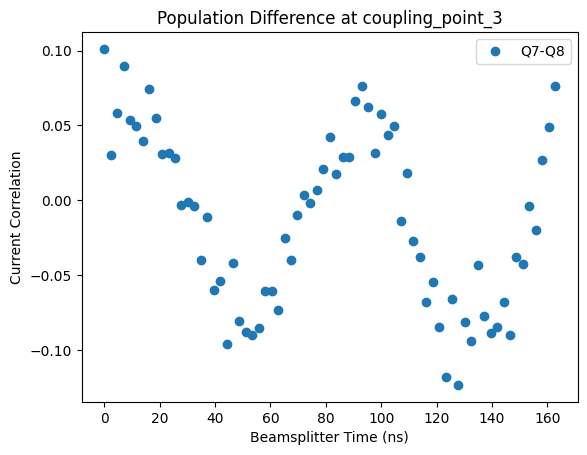

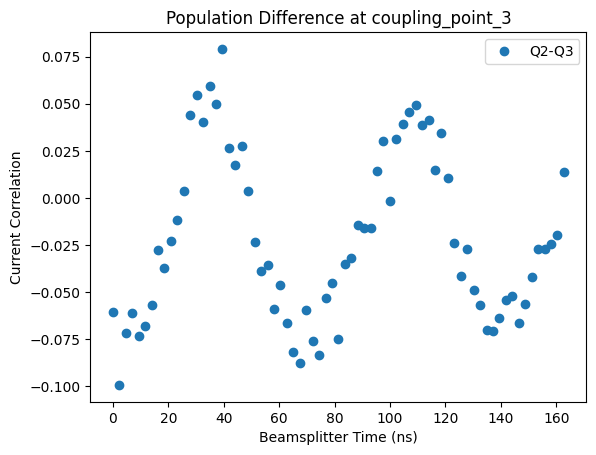

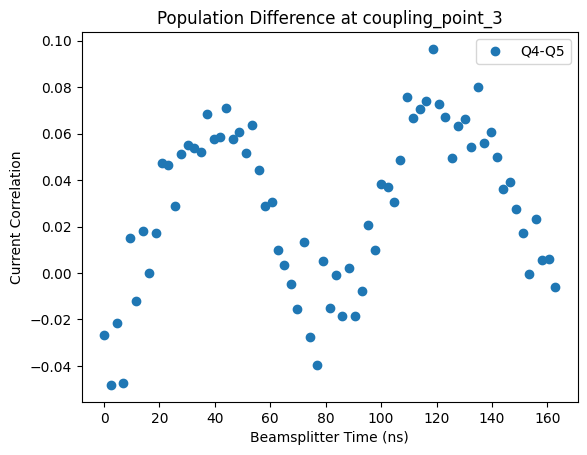

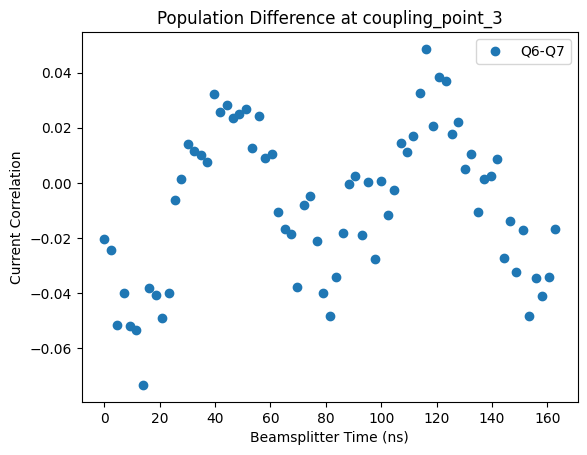

In [ ]:
for pair in pair_to_population_difference:
    plt.plot(pair_to_times[pair], pair_to_population_difference[pair], linestyle='', marker='o', label=f'Q{pair[0]}-Q{pair[1]}')
    plt.xlabel('Beamsplitter Time (ns)')
    plt.ylabel('Current Correlation')
    plt.title(f'Population Difference at {coupling_point}')


    plt.legend()
    plt.show()

# 2. Fit Data

In [ ]:
def sin_fit(t, A, omega, phi, offset):
    return A * np.sin(omega * t + phi) + offset

In [ ]:
initial_guess_dict = {}


initial_guess_dict = {
    (5,6): [-0.06091163346661568, 120, 0, 0.007455102075835023]
}

beamsplitter_time: 0.02 us for pair (1, 2)
initial_guess: [-0.07286545562116731, 65.84778201924206, 0, 0.03927409425021568]


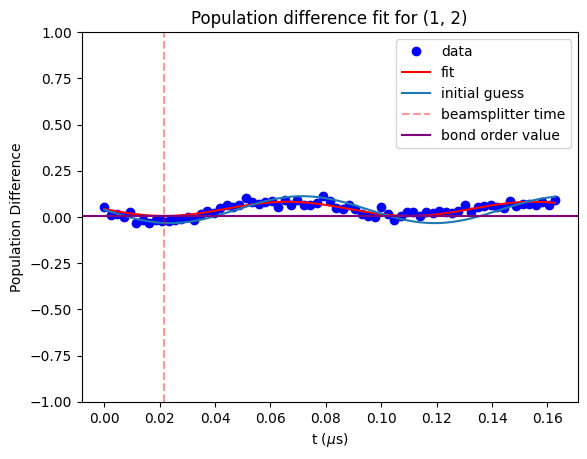

beamsplitter_time: 0.04 us for pair (2, 3)
initial_guess: [0.08917944924316193, 62.70618936565227, 0, -0.021651318739345244]


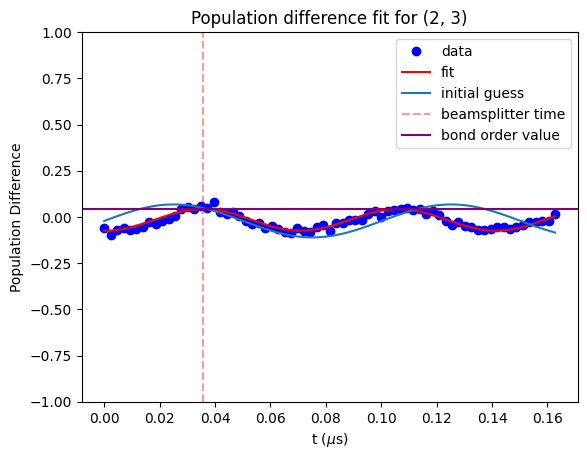

beamsplitter_time: 0.02 us for pair (3, 4)
initial_guess: [-0.05651302653032875, 56.67433147075987, 0, -0.05358750857762577]


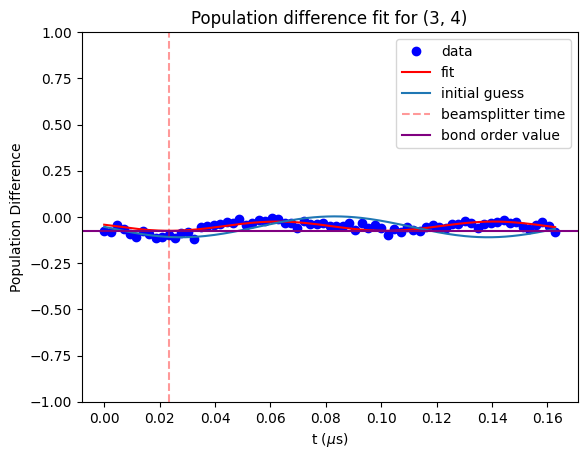

beamsplitter_time: 0.04 us for pair (4, 5)
initial_guess: [0.0723138329103176, 59.1876055936317, 0, 0.028822953486806472]


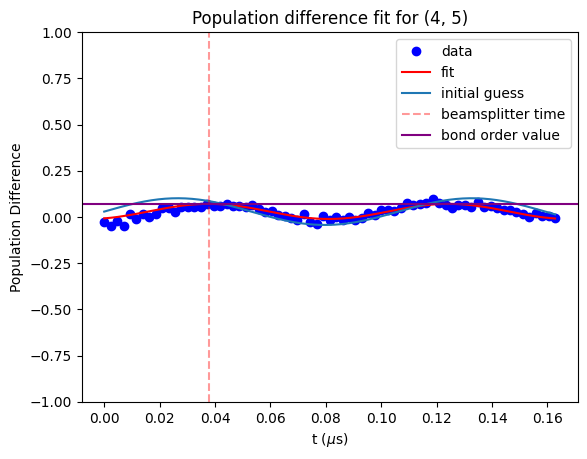

beamsplitter_time: 0.02 us for pair (5, 6)
initial_guess: [-0.06091163346661568, 120, 0, 0.007455102075835023]


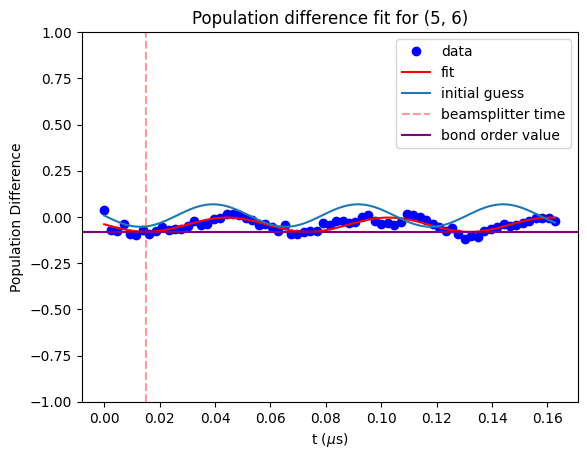

beamsplitter_time: 0.05 us for pair (6, 7)
initial_guess: [0.06091163346661568, 63.46017160251382, 0, -0.007455102075835023]


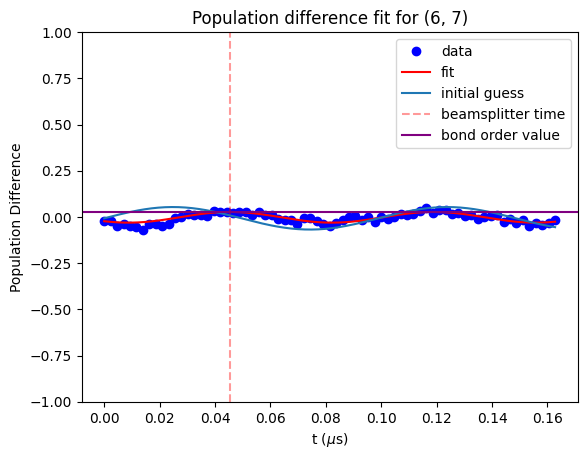

beamsplitter_time: 0.05 us for pair (7, 8)
initial_guess: [-0.11226724767927637, 65.97344572538566, 0, -0.012746306708874451]


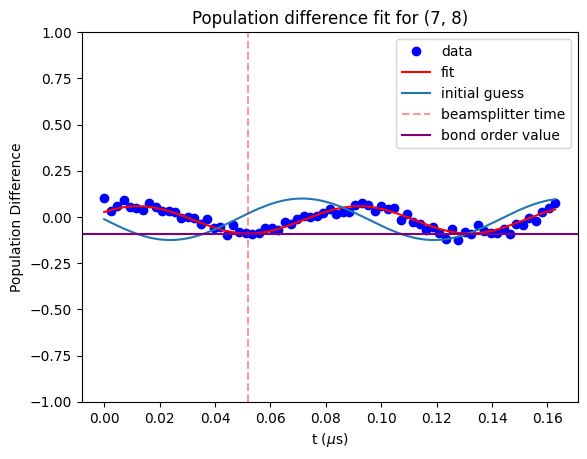

In [ ]:
couplings = coupling_point_config['coupling']

all_pairs = [(i,i+1) for i in range(1,8)]

fit_pairs = [(1,2)]
fit_pairs = [(1,2), (3,4), (5,6), (7,8)]

fit_pairs = all_pairs

# fit_pairs = [(5,6)]

start_cutoff = 10

pair_to_popt = {}
pair_to_perr = {}

pair_to_beamsplitter_time = {}

pair_to_bond_order_parameter = {}
pair_to_bond_order_parameter_corrected = {}

pair_to_bond_order_error = {}
pair_to_bond_order_error_corrected = {}

plot_initial_guess = True


for pair in fit_pairs:
    times = pair_to_times[pair]
    times_mus = times*1e-3
    population_difference = pair_to_population_difference[pair]

    coupling_MHz = abs(couplings[f'J_{pair[0]}{pair[1]}'])

    offset_guess = np.mean(population_difference)
    amplitude_guess = (np.max(population_difference) - np.min(population_difference)) / 2
    frequency_guess = 2 * coupling_MHz * 2 * np.pi

    if pair in initial_guess_dict:
        initial_guess = initial_guess_dict[pair]
    else:
        initial_guess = [amplitude_guess, frequency_guess, 0, offset_guess]

        # compare mean squared error for original vs phase-shifted (pi) initial guesses
        pred_orig = sin_fit(times_mus, *initial_guess)
        mse_orig = np.mean((population_difference - pred_orig)**2)

        initial_guess_neg = initial_guess.copy()
        initial_guess_neg[0] *= -1
        pred_pi = sin_fit(times_mus, *initial_guess_neg)
        mse_pi = np.mean((population_difference - pred_pi)**2)

        if mse_pi < mse_orig:
            initial_guess = initial_guess_neg


    bounds = ((0, 0, 0, -1), (2*amplitude_guess, 4*frequency_guess, 2*np.pi, 1))

    # fit

    popt, pcov = curve_fit(sin_fit, times_mus[start_cutoff:], population_difference[start_cutoff:], p0=initial_guess)
    
    amp, frequency, phase, offset = popt
    perr = np.sqrt(np.diag(pcov))

    beamsplitter_time = (np.pi/2 - phase)/frequency
    while beamsplitter_time < 0:
        beamsplitter_time += 2*np.pi/frequency


    pair_to_popt[pair] = popt
    pair_to_perr[pair] = perr

    pair_to_beamsplitter_time[pair] = beamsplitter_time

    pair_to_bond_order_parameter[pair] = amp + offset
    pair_to_bond_order_parameter_corrected[pair] = amp

    bond_order_error = np.sqrt(perr[0]**2 + perr[3]**2 + 2*pcov[0,3])
    pair_to_bond_order_error[pair] = bond_order_error

    bond_order_error_corrected = perr[0]
    pair_to_bond_order_error_corrected[pair] = bond_order_error_corrected



    print(f'beamsplitter_time: {beamsplitter_time:.2f} us for pair {pair}')

    fit_times = np.linspace(times_mus[0], times_mus[-1], 201)

    plt.plot(times_mus, population_difference, linestyle='', color='blue', marker='o', label='data')

    plt.plot(fit_times, sin_fit(fit_times, *popt), color='red', label='fit')

    if plot_initial_guess:
        print(f'initial_guess: {initial_guess}')
        plt.plot(fit_times, sin_fit(fit_times, *initial_guess), label='initial guess')

    plt.axvline(x=beamsplitter_time, color='red', linestyle='--', label='beamsplitter time', alpha=0.4)

    plt.axhline(y=amp + offset, color='purple', label='bond order value')

    plt.xlabel('t ($\mu$s)')
    plt.ylabel('Population Difference')


    plt.title(f'Population difference fit for {pair}')

    plt.ylim(-1,1)

    plt.legend()
    plt.show()

    

In [ ]:
print(pair_to_bond_order_parameter[(1,2)])

0.005223826392450455


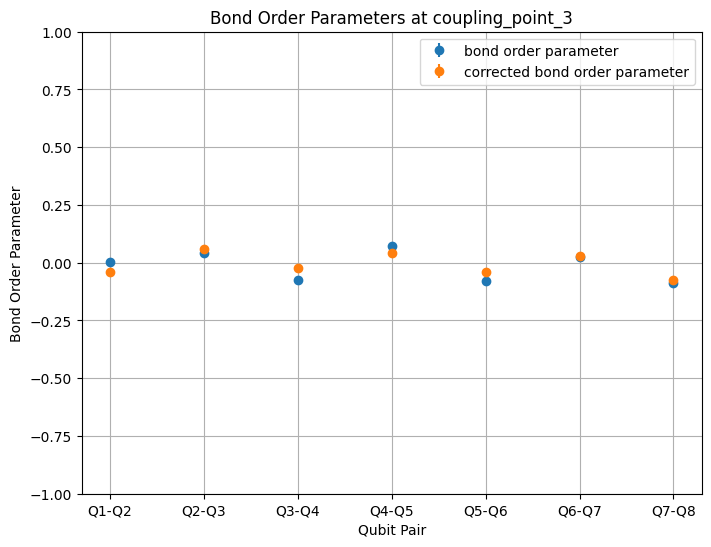

In [ ]:
### plot all bond order parameters
plt.figure(figsize=(8,6))

bond_order_parameters = []
bond_order_parameters_errors = []

bond_order_parameters_corrected = []
bond_order_parameters_errors_corrected = []

pairs = []

for pair in pair_to_bond_order_parameter:


    pairs.append(pair)

    bond_order_parameters.append(pair_to_bond_order_parameter[pair])
    bond_order_parameters_errors.append(pair_to_bond_order_error[pair])

    bond_order_parameters_corrected.append(pair_to_bond_order_parameter_corrected[pair])
    bond_order_parameters_errors_corrected.append(pair_to_bond_order_error_corrected[pair])

plt.errorbar(range(len(pairs)), bond_order_parameters, yerr=bond_order_parameters_errors, fmt='o', label='bond order parameter')
plt.errorbar(range(len(pairs)), bond_order_parameters_corrected, yerr=bond_order_parameters_errors_corrected, fmt='o', label='corrected bond order parameter')

plt.xticks(range(len(pairs)), [f'Q{pair[0]}-Q{pair[1]}' for pair in pairs])
plt.xlabel('Qubit Pair')

plt.ylabel('Bond Order Parameter')
plt.title(f'Bond Order Parameters at {coupling_point}')

plt.ylim(-1, 1)

plt.legend()
plt.grid()
plt.show()  

In [ ]:
# calculate total bond order parameter

bond_order_total = 0
bond_order_total_error = np.sqrt(np.sum(np.power(bond_order_parameters_errors, 2)))


bond_order_total_corrected = 0
bond_order_total_error_corrected = np.sqrt(np.sum(np.power(bond_order_parameters_errors_corrected, 2)))

for i in range(len(bond_order_parameters)):
    bond_order_total += bond_order_parameters[i] * (-1)**i

for i in range(len(bond_order_parameters_corrected)):
    bond_order_total_corrected += bond_order_parameters_corrected[i] * (-1)**i

print(f'Total Bond Order Parameter: {bond_order_total:.4f} ± {bond_order_total_error:.4f}')
print(f'Total Corrected Bond Order Parameter: {bond_order_total_corrected:.4f} ± {bond_order_total_error_corrected:.4f}')

Total Bond Order Parameter: -0.3809 ± 0.0100
Total Corrected Bond Order Parameter: -0.3044 ± 0.0082


# 3. Save data

In [ ]:
data_dictionary = {}

for pair in pair_to_bond_order_parameter:
    data_dictionary[pair] = {}

    data_dictionary[pair]['times'] = pair_to_times[pair]

    data_dictionary[pair]['beamsplitter_time'] = pair_to_beamsplitter_time[pair]

    data_dictionary[pair]['population_difference'] = pair_to_population_difference[pair]
    
    data_dictionary[pair]['bond_order_value'] = pair_to_bond_order_parameter[pair]
    data_dictionary[pair]['bond_order_error'] = pair_to_bond_order_error[pair]

    data_dictionary[pair]['bond_order_value_corrected'] = pair_to_bond_order_parameter_corrected[pair]
    data_dictionary[pair]['bond_order_error_corrected'] = pair_to_bond_order_error_corrected[pair]

data_dictionary['bond_order_total'] = bond_order_total
data_dictionary['bond_order_total_error'] = bond_order_total_error

data_dictionary['bond_order_total_corrected'] = bond_order_total_corrected
data_dictionary['bond_order_total_error_corrected'] = bond_order_total_error_corrected

In [ ]:
def backup_data(data_filename):
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename_only = os.path.basename(data_filename)
    name, ext = os.path.splitext(filename_only)
    backup_name = f"{name}_{timestamp}{ext}"
    backup_path = os.path.join('data_backups', backup_name)
    shutil.copy2(data_filename, backup_path)

def save_nested_dict_to_hdf5(filename, data, save_backup=True):

    if save_backup:
        backup_data(filename)

    with h5py.File(filename, 'w') as f:
        def _save_dict(group, dictionary):
            for key, value in dictionary.items():
                if isinstance(value, dict):
                    subgroup = group.create_group(str(key))
                    _save_dict(subgroup, value)
                elif isinstance(value, np.ndarray):
                    group.create_dataset(key, data=value, compression='gzip')
                elif isinstance(value, list):
                    group.create_dataset(key, data=np.array(value), compression='gzip')
                else:
                    group.attrs[key] = value  # Store scalars as attributes
        
        _save_dict(f, data)

def update_data_file(filename, data, keys, save_backup=True):
    if save_backup:
        backup_data(filename)
    
    with h5py.File(filename, 'a') as f:  # Open in append mode
        def _navigate_to_parent(group, key_path):
            """Navigate to the parent group of the target location"""
            current_group = group
            for key in key_path[:-1]:  # All keys except the last one
                if str(key) in current_group:
                    current_group = current_group[str(key)]
                else:
                    # Create the group if it doesn't exist
                    current_group = current_group.create_group(str(key))
            return current_group
        
        def _save_data_at_location(group, key, value):
            """Save data at a specific location, replacing if it exists"""
            # Remove existing data if it exists
            if key in group:
                del group[key]
            
            # Save new data
            if isinstance(value, dict):
                subgroup = group.create_group(key)
                _save_dict(subgroup, value)
            elif isinstance(value, np.ndarray):
                group.create_dataset(key, data=value, compression='gzip')
            elif isinstance(value, list):
                group.create_dataset(key, data=np.array(value), compression='gzip')
            else:
                group.attrs[key] = value  # Store scalars as attributes
        
        def _save_dict(group, dictionary):
            """Helper function to save nested dictionaries"""
            for key, value in dictionary.items():
                _save_data_at_location(group, str(key), value)
        
        # Navigate to the parent location
        parent_group = _navigate_to_parent(f, keys)
        
        # Save the data at the final key location
        final_key = str(keys[-1])
        _save_data_at_location(parent_group, final_key, data)

In [ ]:
# # this overwrits the whole file !!! be careful

# data_filename = 'bond_order_data.h5'
# save_nested_dict_to_hdf5(data_filename, {'data': {coupling_point: {eigenstate: data_dictionary}}})

In [ ]:
data_filename = 'bond_order_data.h5'

keys = ('data', coupling_point, eigenstate)

update_data_file(data_filename, data_dictionary, keys=keys, save_backup=True)
